# 08 · Merged analyzers: full-year QC fluxes

The two analyzers cover complementary halves of 2021: the QCL runs in campaign
2021_1 (January to 20 July) and the LGR in campaign 2021_2 (22 July to December).
Concatenating them over time gives one continuous **full-year** series per
variant. This notebook merges the two and plots the merged, quality-controlled
flux for the whole of 2021.

Fluxes are the USTAR-filtered QC fluxes from the flux processing chain
([notebook 05](05_flux_processing_chain.ipynb)); the merge just stitches the QCL
and LGR halves together at the campaign boundary (a light dashed line marks the
handover).

Two figures are produced, one per gas:

- **N2O:** the five variants as columns, each a merged full-year series, with the
  QC flux (top), the merged time lag used (middle), and a histogram of that lag
  with its mode highlighted (bottom). Saved as
  `figures/08_{scenario}_merged_n2o.png`.
- **CH4:** the same, for methane. Saved as `figures/08_{scenario}_merged_ch4.png`.

Inputs:
- `data/05-flux_processing_chain_parquet/` for the QC fluxes.
- `data/02-…_subsets/` and `data/01-pwb_tlag_summary_parquet/` for the time lag
  (the chain output does not carry it).

## Imports

In [6]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from diive.core.io.files import load_parquet

# White figure background (on screen and in saved PNGs).
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

`USTAR_SCENARIO` selects which of the three USTAR-filtered fluxes to plot. The
five variants are the columns; each column is the QCL half and the LGR half of
that variant merged into one full-year series. The lag for variants `*-1` to
`*-4` is the EddyPro time lag used, while the PWB$_{OPT}$ column (`*-5`) uses its
optimised lag (the PWB estimate after the S1/S2/S3 decision rule). The
constant-lag variant (`*-4`) carries two constants here, one per campaign, so its
histogram row shows a single filled bin at each constant rather than a spread.

Method abbreviations follow Vitale et al. (2024): CM = covariance maximisation,
CM$_{CTR}$ = constrained CM (narrow window), PWB$_{OPT}$ = optimised
pre-whitening with block-bootstrap.

In [7]:
FPCDIR = Path("../data/05-flux_processing_chain_parquet")              # QC fluxes
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")  # lag, *-1..*-4
PWBDIR = Path("../data/01-pwb_tlag_summary_parquet")                   # lag, *-5
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

YEAR = 2021
USTAR_SCENARIO = "CUT_50"  # one of CUT_16 / CUT_50 / CUT_84

FIGSIZE = (16, 9)
DPI = 300

# The two analyzers cover complementary halves of the year; QCL is the earlier
# campaign (plotted first), LGR the later one.
ANALYZERS = ["QCL", "LGR"]
# Columns = the five time-lag variants; each is merged across both analyzers.
VARIANTS = [1, 2, 3, 4, 5]
PWB_VARIANT = 5  # the PWB variant uses its detected lag, not the EddyPro lag

# Column titles: what each variant does to find the time lag (see
# docs/processing-versions.md). Method abbreviations follow Vitale et al. (2024):
# CM = covariance maximisation, subscript CTR = constrained (narrow window), PWB =
# pre-whitening with block-bootstrap. Variant *-5 uses the optimised lag PWB_OPT
# (the S1/S2/S3 decision rule applied to the PWB estimates), so it is labelled as
# such; the lag column read below (*_tlag_final_pf_s) is exactly that PWB_OPT lag.
VARIANT_NAMES = {
    1: "CM\nwide, no default",
    2: "CM\nwide, default",
    3: "CM$_{CTR}$\nnarrow, default",
    4: "Constant lag",
    5: "PWB$_{OPT}$",
}

# Per gas: the flux variable, the EddyPro time-lag-used variable, and the PWB_OPT
# optimised-lag column.
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED", "pwb_lag": "n2o_tlag_final_pf_s"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED", "pwb_lag": "ch4_tlag_final_pf_s"},
}

# One color per instrument, used across all three rows (flux, lag, density).
# Distinct but from neighbouring hues, so the figure stays cohesive.
INSTRUMENT_COLORS = {"QCL": "#3182bd", "LGR": "#e67e22"}  # blue, orange

# Pretty gas labels for axis text and titles.
GAS_LABEL = {"N2O": "N$_2$O", "CH4": "CH$_4$"}

BIN_S = 0.05                 # tlag raster (s); the mode is snapped to this grid
PCTL = (1, 99)              # robust flux y-range percentiles
SEARCH_WINDOW = (0.0, 10.0)  # covariance-maximization search window (s)
FRINGE_MARGIN = 0.1          # peak search ignores lags within this of the rails


def qc_col(fluxvar, scenario):
    """Name of the USTAR-filtered, QCF-accepted flux column in the fpc output."""
    return f"{fluxvar}_L3.1_L3.3_{scenario}_QCF"


print(f"Merging {ANALYZERS} into full-year series, USTAR scenario: {USTAR_SCENARIO}")

Merging ['QCL', 'LGR'] into full-year series, USTAR scenario: CUT_50


## Load and merge the QC fluxes and the time lag

For each analyzer, variant and gas the QC flux is pulled from its `*_fpc.parquet`
(the single `USTAR_SCENARIO` column) and the time lag from the column subsets
(`*-1` to `*-4`) or the PWB summaries (`*-5`). The two analyzers are then
concatenated over time per variant. Because the campaigns do not overlap, this is
a clean stitch: no timestamp appears in both halves.

In [8]:
def _yr(df):
    return df.loc[df.index.year == YEAR]


# Per-analyzer QC flux and lag, then merged full-year series keyed by (variant, gas).
qcflux, lag_used = {}, {}          # per (analyzer, variant, gas)
merged_flux, merged_lag = {}, {}   # per (variant, gas): full-year series
boundary = {}                       # campaign handover per analyzer pair

for var in VARIANTS:
    for analyzer in ANALYZERS:
        code = f"{analyzer}-{var}"
        # Lag source: PWB summary for the PWB variant, subset otherwise.
        if var == PWB_VARIANT:
            lagdf = _yr(load_parquet(filepath=str(PWBDIR / f"{code}_pwb_tlag.parquet")))
        else:
            lagdf = _yr(load_parquet(filepath=str(SUBSETDIR / f"{code}.parquet")))
        for gas, v in GASES.items():
            df = _yr(load_parquet(filepath=str(FPCDIR / f"{code}_{v['flux']}_fpc.parquet")))
            qcflux[(analyzer, var, gas)] = df[qc_col(v["flux"], USTAR_SCENARIO)]
            lagcol = v["pwb_lag"] if var == PWB_VARIANT else v["lag"]
            lag_used[(analyzer, var, gas)] = lagdf[lagcol]

    for gas in GASES:
        merged_flux[(var, gas)] = pd.concat(
            [qcflux[(a, var, gas)] for a in ANALYZERS]).sort_index()
        merged_lag[(var, gas)] = pd.concat(
            [lag_used[(a, var, gas)] for a in ANALYZERS]).sort_index()

# Campaign handover: midpoint between the last QCL and first LGR timestamp
# (identical across variants/gases; take it from variant 1, N2O).
_qcl_end = qcflux[("QCL", 1, "N2O")].index.max()
_lgr_start = qcflux[("LGR", 1, "N2O")].index.min()
HANDOVER = _qcl_end + (_lgr_start - _qcl_end) / 2

for var in VARIANTS:
    s = merged_flux[(var, "N2O")]
    print(f"variant -{var}: {int(s.notna().sum())} valid merged QC N2O "
          f"({s.index.min():%Y-%m-%d} to {s.index.max():%Y-%m-%d})")
print(f"campaign handover marked at {HANDOVER:%Y-%m-%d %H:%M}")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.004 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FN2O_fpc.parquet (0.007 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FCH4_fpc.parquet (0.006 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-1.parquet (0.002 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-1_FN2O_fpc.parquet (0.004 seconds).

...

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-5_FCH4_fpc.parquet (0.006 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\LGR-5_pwb_tlag.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FN2O_fpc.parquet (0.005 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\LGR-5_FCH4_fpc.parquet (0.004 seconds).

variant -1: 11337 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -2: 11235 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -3: 10299 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -4: 9676 valid merged QC N2O (2021-01-01 to 2021-12-31)
variant -5: 9652 valid merged QC N2O (2021-01-01 to 2021-12-31)
campaign handover marked at 2021-07-21 13:15


## Figures: merged full-year QC flux, time lag, lag histogram

One figure per gas. Three rows (QC flux over time, time lag used over time, lag
histogram) with the five variants as columns. The two instruments carry one
color each (QCL blue, LGR yellow-orange), used consistently across all three rows;
the top-left flux panel carries the instrument legend, and a light dashed line
marks the QCL to LGR handover in the top two rows.

The bottom row overlays the two instruments' lag histograms, binned on the EddyPro
tlag raster (0.05 s bins, one bar per reported lag value), drawn with time lag on
the vertical axis and count on the horizontal axis, so it reads as a rotated
histogram aligned with the lag row above it. The two instruments' bars are
overlaid (not stacked) and semi-transparent, so both stay visible where they
overlap. Within each row the y-axis is shared across the columns (only the first
column shows y tick labels): flux, time lag, and now also the histogram row's
time-lag axis. The shared count axis is scaled to the PWB$_{OPT}$ variant's tallest
bar, so every column is read against the PWB method's peak count; the more
concentrated variants (the narrow-window CM, and the single-bin constant lag) have
taller bars that run past the right edge. Each instrument's modal lag is printed in
the upper-right corner of the panel, coloured by instrument (`Mode QCL` above,
`Mode LGR` below). The mode is the peak 0.05 s bin of the non-fringe lags, so it
lands on the grid (e.g. 0.65 s) and the 0 s / 10 s search window rails (mostly
`*-1`) cannot be mistaken for it. The constant-lag variant (`*-4`) is single-valued
per campaign, so its whole record falls into one 0.05 s bin (that bar overshoots
the count axis and reaches the right edge).

Saved ..\figures\08_cut_50_merged_n2o.png


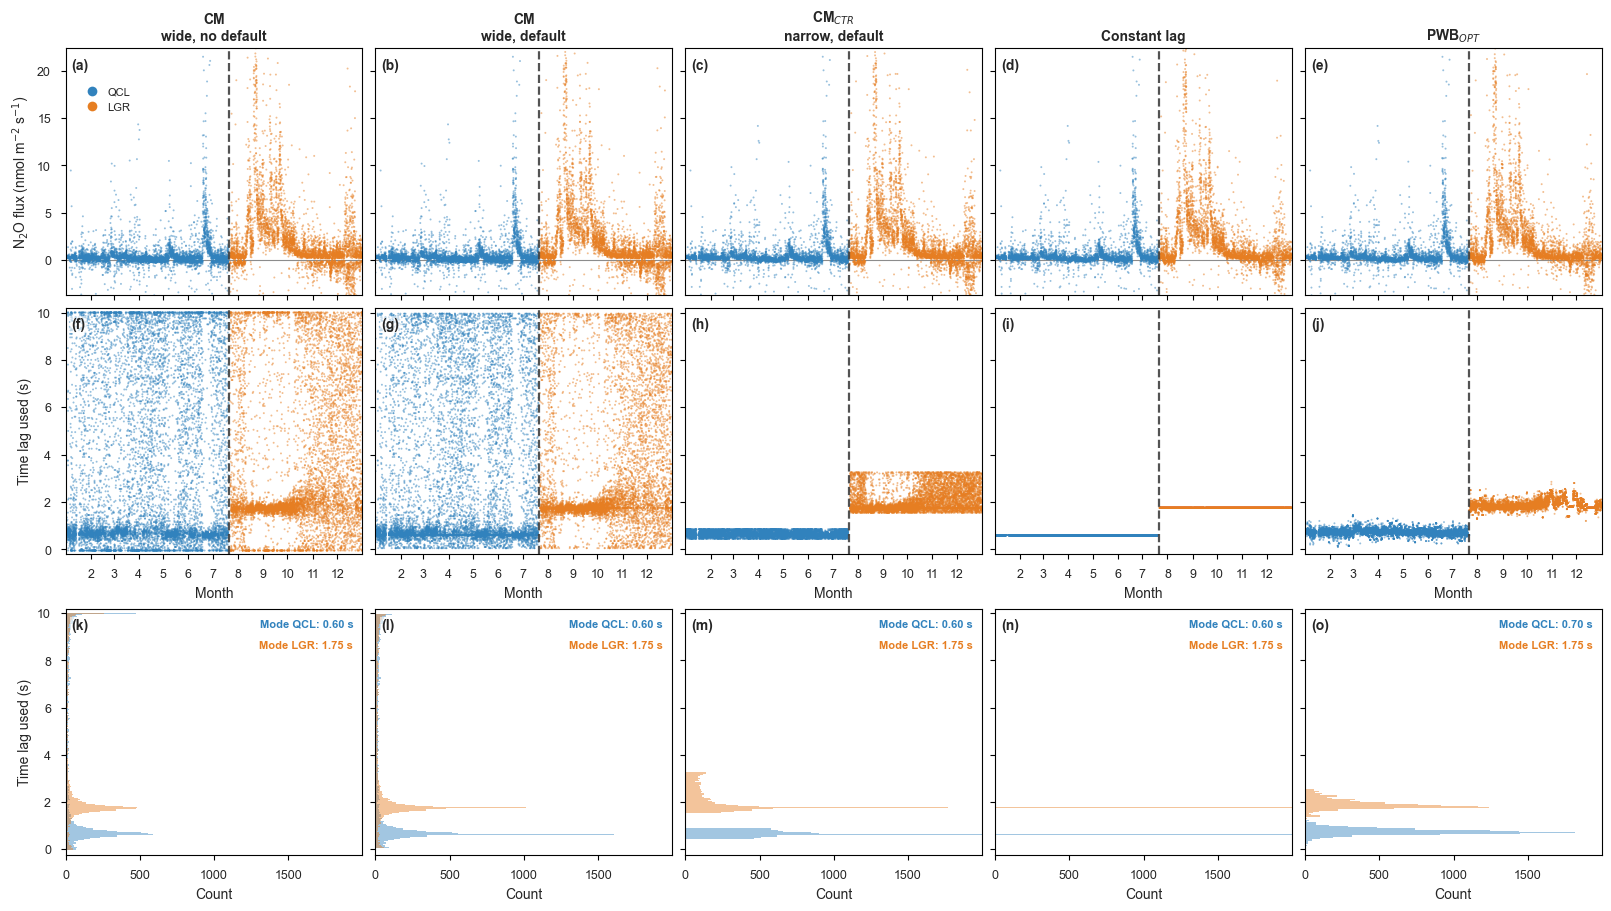

Saved ..\figures\08_cut_50_merged_ch4.png


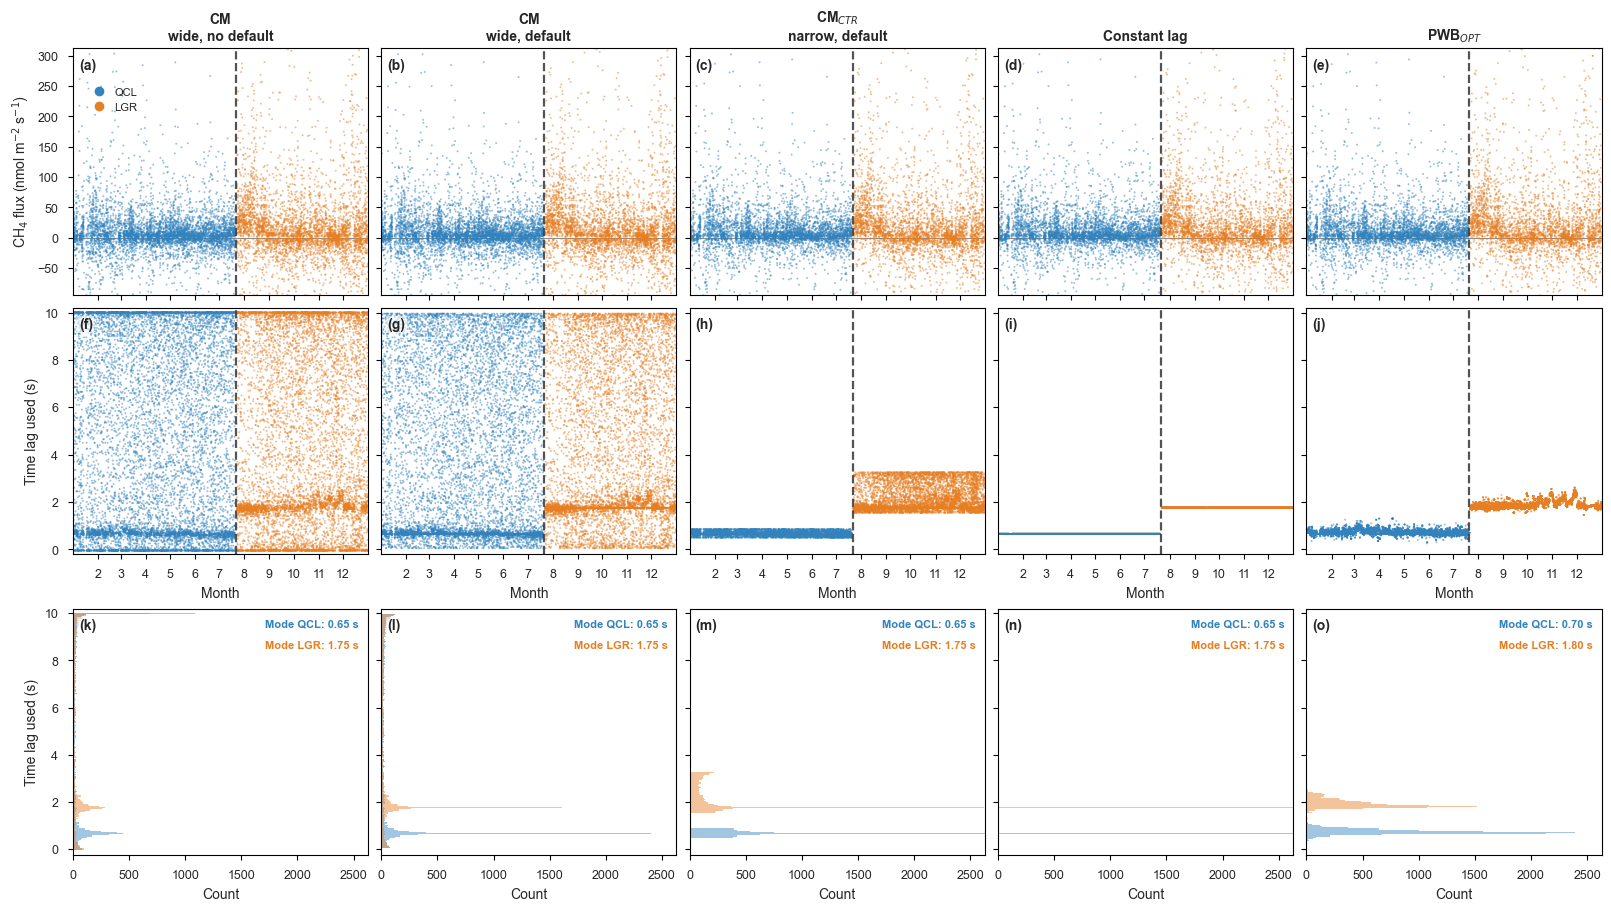

In [9]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


LAG_YLIM = (-0.2, 10.2)  # full 0 to 10 s search window with a small pad
LO_EDGE = SEARCH_WINDOW[0] + FRINGE_MARGIN
HI_EDGE = SEARCH_WINDOW[1] - FRINGE_MARGIN
MARKER_S = 2       # scatter marker size for the flux and lag rows
LETTERS = "abcdefghijklmnopqrstuvwxyz"
# Histogram bins match the EddyPro tlag raster (BIN_S = 0.05 s) and are centred on
# the raster multiples, so each bar sits exactly on a reported lag value.
HIST_EDGES = np.arange(SEARCH_WINDOW[0] - BIN_S / 2, SEARCH_WINDOW[1] + BIN_S, BIN_S)
HIST_CENTERS = 0.5 * (HIST_EDGES[:-1] + HIST_EDGES[1:])  # bar centres on the lag axis
# Upper-right corner rows for the two instruments' modal-lag labels (axes fraction).
LABEL_YFRAC = (0.96, 0.87)


def month_int(x, pos):
    """Format a date tick as its (integer) month number, no year."""
    return f"{mdates.num2date(x).month}"


def panel_letter(ax, text):
    """Bold panel letter in the top-left corner, over a faint white patch."""
    ax.text(0.02, 0.96, f"({text})", transform=ax.transAxes, va="top", ha="left",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none", alpha=0.6))


def style_axes(ax):
    """Black spines, short outward major/minor ticks, no grid."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(which="major", length=3.5, width=0.8, direction="out", color="black")
    ax.tick_params(which="minor", length=2.0, width=0.6, direction="out", color="black")


def lag_counts(values):
    """Histogram counts of a lag series on the fixed HIST_EDGES (0.05 s raster).
    The constant-lag variant is single-valued, so it lands entirely in one bin
    (that bar overshoots the PWB-scaled count axis and reaches the right edge).
    Returns None only for an empty or too-short series."""
    v = np.asarray(pd.Series(values).dropna(), dtype=float)
    if v.size < 5:
        return None
    return np.histogram(v, bins=HIST_EDGES)[0]


def mode_on_grid(values):
    """Modal lag snapped to the BIN_S (0.05 s) tlag raster: the peak 0.05 s bin of
    the non-fringe lags (so the 0 s / 10 s rails cannot be the mode), e.g. 0.65 s.
    Matches how EddyPro reports the lag, so the reported value sits on the grid
    rather than on the finer histogram axis. Returns None if no non-fringe lag
    exists."""
    s = pd.Series(values).dropna()
    s = s[(s > LO_EDGE) & (s < HI_EDGE)]
    if s.empty:
        return None
    lo_k = int(np.floor(s.min() / BIN_S))
    hi_k = int(np.ceil(s.max() / BIN_S))
    edges = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S  # bins centred on k * BIN_S
    counts, _ = np.histogram(s, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return float(centers[int(np.argmax(counts))])


# Legend proxies for the two instruments (shown in the top-left flux panel).
inst_handles = [Line2D([0], [0], marker="o", linestyle="", markersize=7,
                       color=INSTRUMENT_COLORS[a], label=a) for a in ANALYZERS]

for gas in GASES:
    columns = VARIANTS
    ncols = len(columns)
    glabel = GAS_LABEL[gas]

    # Flux y-range across both instruments and all variants. For N2O the upper
    # limit is the 99.5th percentile, high enough to show most of the tall N2O
    # peaks while clipping the few extreme outliers that would otherwise squash the
    # bulk of the data; the lower limit keeps the robust 1st percentile. CH4 uses
    # the symmetric robust range.
    flux_vals = np.concatenate(
        [merged_flux[(var, gas)].to_numpy().ravel() for var in columns])
    if gas == "N2O":
        lo, hi = np.nanpercentile(flux_vals, (PCTL[0], 99.5))
        pad = 0.05 * (hi - lo)
        flux_ylim = (lo - pad, hi + pad)
    else:
        flux_ylim = robust_ylim(flux_vals)

    # Common lag range for the histogram row (data-driven, shared across columns).
    # The histogram row plots time lag on the vertical axis, so this is its y-range.
    all_lag = np.concatenate(
        [lag_used[(a, var, gas)].dropna().to_numpy()
         for var in columns for a in ANALYZERS])
    lag_range = (float(np.nanmin(all_lag)) - 0.2, float(np.nanmax(all_lag)) + 0.2)

    # Pre-compute each column/instrument lag histogram (bin counts) and its
    # raster-snapped mode.
    hist_cache = {}
    for var in columns:
        for a in ANALYZERS:
            counts = lag_counts(lag_used[(a, var, gas)])
            m = mode_on_grid(lag_used[(a, var, gas)])
            hist_cache[(var, a)] = (counts, m)

    # Scale the shared count axis to the PWB_OPT variant's tallest bar, so every
    # column is read against the PWB method's peak count. Taller bars from the more
    # concentrated variants (the narrow-window CM, and the single-bin constant lag)
    # run past the right edge.
    count_max = max(
        (float(hist_cache[(PWB_VARIANT, a)][0].max())
         for a in ANALYZERS if hist_cache[(PWB_VARIANT, a)][0] is not None),
        default=1.0)
    count_xlim = (0, count_max * 1.1)

    fig, axes = plt.subplots(nrows=3, ncols=ncols,
                             figsize=FIGSIZE, constrained_layout=True)

    for ci, var in enumerate(columns):
        ax_flux, ax_lag, ax_hist = axes[0, ci], axes[1, ci], axes[2, ci]

        ax_lag.sharex(ax_flux)
        # Within each row the y-axis is shared across columns; only the first
        # column keeps its y tick labels.
        if ci > 0:
            ax_flux.sharey(axes[0, 0])
            ax_lag.sharey(axes[1, 0])
            ax_hist.sharey(axes[2, 0])
            for ax in (ax_flux, ax_lag, ax_hist):
                ax.tick_params(labelleft=False)
        for r, ax in enumerate((ax_flux, ax_lag, ax_hist)):
            style_axes(ax)
            panel_letter(ax, LETTERS[r * ncols + ci])
        ax_flux.set_title(VARIANT_NAMES[var], fontweight="bold", fontsize=10)

        # Rows 1 and 2: QC flux and time lag over time, one color per instrument.
        ax_flux.axhline(0, color="0.55", lw=0.8, zorder=0.5)  # zero reference
        for a in ANALYZERS:
            c = INSTRUMENT_COLORS[a]
            f = qcflux[(a, var, gas)].dropna()
            ax_flux.scatter(f.index, f, s=MARKER_S, alpha=0.5, color=c, edgecolors="none")
            lg = lag_used[(a, var, gas)].dropna()
            ax_lag.scatter(lg.index, lg, s=MARKER_S, alpha=0.5, color=c, edgecolors="none")
        for ax in (ax_flux, ax_lag):
            ax.axvline(HANDOVER, color="0.25", lw=1.6, ls="--", alpha=0.9)
        ax_flux.set_ylim(flux_ylim)
        if gas == "N2O":
            # Flux tick labels in steps of 5 on the top row for N2O.
            ax_flux.yaxis.set_major_locator(mticker.MultipleLocator(5))
        ax_flux.tick_params(labelbottom=False)
        ax_lag.set_ylim(*LAG_YLIM)
        # Time axis: every month is a major tick, labelled with its integer month
        # number 2 to 12 (no year); no minor ticks. A "Month" axis label.
        ax_lag.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax_lag.xaxis.set_major_formatter(mticker.FuncFormatter(month_int))
        ax_lag.xaxis.set_minor_locator(mticker.NullLocator())
        ax_lag.set_xlabel("Month")
        span = merged_lag[(var, gas)].index
        ax_lag.set_xlim(span.min(), span.max())

        # Row 3: lag histogram (bin counts) per instrument, time lag on the vertical
        # axis and count on the horizontal axis (a rotated histogram aligned with
        # the lag row above). The two instruments' bars are overlaid (not stacked)
        # and semi-transparent so both stay visible where they overlap. Each
        # instrument's modal lag (peak 0.05 s bin, EddyPro tlag raster) is printed in
        # the upper-right corner, coloured by instrument. The constant-lag variant is
        # single-valued, so its whole record falls in one 0.05 s bin whose bar
        # overshoots the PWB-scaled count axis and reaches the right edge.
        for i, a in enumerate(ANALYZERS):
            c = INSTRUMENT_COLORS[a]
            counts, m = hist_cache[(var, a)]
            if counts is not None:
                ax_hist.barh(HIST_CENTERS, counts, height=BIN_S, color=c,
                             alpha=0.45, align="center", linewidth=0, zorder=1)
            if m is None:
                continue
            # Modal lag printed in the upper-right corner, coloured by instrument.
            ax_hist.text(0.97, LABEL_YFRAC[i], f"Mode {a}: {m:.2f} s",
                         transform=ax_hist.transAxes, ha="right", va="top",
                         fontsize=8, fontweight="bold", color=c, zorder=6)
        ax_hist.set_xlim(*count_xlim)
        ax_hist.set_xlabel("Count")

    # Shared time-lag axis for the bottom (histogram) row (set once; sharey propagates).
    axes[2, 0].set_ylim(*lag_range)

    axes[0, 0].set_ylabel(f"{glabel} flux (nmol m$^{{-2}}$ s$^{{-1}}$)")
    axes[1, 0].set_ylabel("Time lag used (s)")
    axes[2, 0].set_ylabel("Time lag used (s)")
    axes[0, 0].legend(handles=inst_handles, loc="upper left",
                      bbox_to_anchor=(0.02, 0.88), fontsize=8, framealpha=0.9,
                      handletextpad=0.4, borderpad=0.3)

    out = FIGDIR / f"08_{USTAR_SCENARIO.lower()}_merged_{gas.lower()}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()

## Runtime

In [10]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-07-11 22:48:43
End:      2026-07-11 22:48:58
Runtime:  0:00:14.651154
